In [ ]:
#Section 1

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
data = pd.read_csv("f1_pitstops_2018_2024.csv")
data.head()  # we do this to read the data


,Season,Round,Circuit,Driver,Constructor,Laps,Position,TotalPitStops,AvgPitStopTime,Race Name,...,Tire Usage Aggression,Fast Lap Attempts,Position Changes,Driver Aggression Score,Abbreviation,Stint,Tire Compound,Stint Length,Pit_Lap,Pit_Time
0,2018,1,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58,1,1,21.787,Australian Grand Prix,...,0.017241,44.76882,0.000000,6.755003,VET,1.0,ULTRASOFT,25.0,26.0,21.787
1,2018,1,Albert Park Grand Prix Circuit,Sebastian Vettel,Ferrari,58,1,1,21.787,Australian Grand Prix,...,0.017241,44.76882,0.000000,6.755003,VET,2.0,SOFT,32.0,NaN,Final Stint
2,2018,1,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58,2,1,21.821,Australian Grand Prix,...,0.017241,44.73482,0.043478,6.754254,HAM,1.0,ULTRASOFT,17.0,19.0,21.821
3,2018,1,Albert Park Grand Prix Circuit,Lewis Hamilton,Mercedes,58,2,1,21.821,Australian Grand Prix,...,0.017241,44.73482,0.043478,6.754254,HAM,2.0,SOFT,39.0,NaN,Final Stint
4,2018,1,Albert Park Grand Prix Circuit,Kimi RÃƒÂ¤ikkÃƒÂ¶nen,Ferrari,58,3,1,21.421,Australian Grand Prix,...,0.017241,45.13482,0.086957,6.818562,RAI,1.0,ULTRASOFT,17.0,18.0,21.421


In [ ]:
data.info() #we do this to see if we have any null values
data.dropna(inplace=True) #returns data with only non-null values, (drops rows with missing stuff)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7374 entries, 0 to 7373
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Season                   7374 non-null   int64  
 1   Round                    7374 non-null   int64  
 2   Circuit                  7374 non-null   object 
 3   Driver                   7374 non-null   object 
 4   Constructor              7374 non-null   object 
 5   Laps                     7374 non-null   int64  
 6   Position                 7374 non-null   int64  
 7   TotalPitStops            7374 non-null   int64  
 8   AvgPitStopTime           7189 non-null   float64
 9   Race Name                7001 non-null   object 
 10  Date                     7001 non-null   object 
 11  Time_of_race             7001 non-null   object 
 12  Location                 7001 non-null   object 
 13  Country                  7001 non-null   object 
 14  Air_Temp_C              

In [ ]:
data.info() #reload the new data

<class 'pandas.core.frame.DataFrame'>
Index: 4334 entries, 0 to 7371
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Season                   4334 non-null   int64  
 1   Round                    4334 non-null   int64  
 2   Circuit                  4334 non-null   object 
 3   Driver                   4334 non-null   object 
 4   Constructor              4334 non-null   object 
 5   Laps                     4334 non-null   int64  
 6   Position                 4334 non-null   int64  
 7   TotalPitStops            4334 non-null   int64  
 8   AvgPitStopTime           4334 non-null   float64
 9   Race Name                4334 non-null   object 
 10  Date                     4334 non-null   object 
 11  Time_of_race             4334 non-null   object 
 12  Location                 4334 non-null   object 
 13  Country                  4334 non-null   object 
 14  Air_Temp_C               4334

In [ ]:
TARGET_COLUMN = 'Lap Time Variation'   # the thing we want to predict (change name if needed)
CONSTRUCTOR_COL = 'Constructor'        # column that holds the team name
DATA_PATH = "f1_pitstops_2018_2024.csv"
   # path to the CSV file

In [ ]:
TOP_TEAMS = ["Mercedes" , "Ferrari", "Red Bull"]


OTHER_TEAMS = ["Sauber", "Toro Rosso", "Haas F1 Team", "Williams", "Force India", "Renault", "AlphaTauri", "Aston Martin", "McLaren", "Alpine", "Alpine", "Racing Point", "Visa Cash App R8 F1 Team", "Stake F1 Team Kick Sauber"]

def get_team_tier(team):
    if team in TOP_TEAMS:
        return "Top_Tier"
    return "Other_Tier"

In [ ]:

#Section 2-Loading and cleaning the data

print("Loading data")

LAPS_BEFORE_df = pd.read_csv(DATA_PATH)
print(f"Data loaded: {LAPS_BEFORE_df.shape[0]:,} rows and {LAPS_BEFORE_df.shape[1]} columns.")

print("\nData set columns:")
print(LAPS_BEFORE_df.columns.tolist())

# get rid of missing target values
before_rows = len(LAPS_BEFORE_df)
raw_laps_df = LAPS_BEFORE_df.dropna(subset=[TARGET_COLUMN]).copy()
after_rows = len(raw_laps_df)
dropped_target = before_rows - after_rows

print(f"\nRemoved {dropped_target} laps where '{TARGET_COLUMN}' was missing.")
print(f"Remaining laps: {after_rows:,}")

# pick my features
feature_columns = ["Stint Length", "Air_Temp_C", "Tire Compound", "Constructor"]

print("\nFeatures:")
print(feature_columns)

# grab just the columns i need
clean_laps_df = raw_laps_df[feature_columns + [TARGET_COLUMN]].copy()

# remove rows with missing data
clean_laps_df = clean_laps_df.dropna(subset=["Stint Length", "Air_Temp_C"])

print("\nFirst few rows:")
print(clean_laps_df.head())

# add team category
team_cats = []
for team in clean_laps_df["Constructor"]:
    team_cats.append(get_team_tier(team))
clean_laps_df["Team_Category"] = team_cats

clean_laps_df = clean_laps_df.drop(columns=["Constructor"])

# turn categories into numbers
laps_encoded = pd.get_dummies(clean_laps_df, columns=["Tire Compound", "Team_Category"], drop_first=False)

print("\nColumns after encoding:")
print(laps_encoded.columns.tolist())

# split into inputs and target
feature_columns = []
for col in laps_encoded.columns:
    if col != TARGET_COLUMN:
        feature_columns.append(col)

X = laps_encoded[feature_columns]
y = laps_encoded[TARGET_COLUMN]

print(f"\nX has {X.shape[0]:,} rows and {X.shape[1]} features.")
print(f"y has {len(y):,} values.")

# split into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10)

print(f"\nTraining set: {X_train.shape[0]:,} laps")
print(f"Test set: {X_test.shape[0]:,} laps")

Loading data
Data loaded: 7,374 rows and 30 columns.

Data set columns:
['Season', 'Round', 'Circuit', 'Driver', 'Constructor', 'Laps', 'Position', 'TotalPitStops', 'AvgPitStopTime', 'Race Name', 'Date', 'Time_of_race', 'Location', 'Country', 'Air_Temp_C', 'Track_Temp_C', 'Humidity_%', 'Wind_Speed_KMH', 'Lap Time Variation', 'Total Pit Stops', 'Tire Usage Aggression', 'Fast Lap Attempts', 'Position Changes', 'Driver Aggression Score', 'Abbreviation', 'Stint', 'Tire Compound', 'Stint Length', 'Pit_Lap', 'Pit_Time']

Removed 185 laps where 'Lap Time Variation' was missing.
Remaining laps: 7,189

Features:
['Stint Length', 'Air_Temp_C', 'Tire Compound', 'Constructor']

First few rows:
   Stint Length  Air_Temp_C Tire Compound Constructor  Lap Time Variation
0          25.0   15.783333     ULTRASOFT     Ferrari            0.001723
1          32.0   15.783333          SOFT     Ferrari            0.001723
2          17.0   15.783333     ULTRASOFT    Mercedes            0.001735
3          39

In [ ]:
# Bias is defined as the absolute difference in MAE
# between Top-Tier and Other-Tier teams.

#SECTION 3: Bias proof (unified model)

# make model
unified_model = DecisionTreeRegressor(random_state=42, max_depth=6, min_samples_leaf=20)
unified_model.fit(X_train, y_train)

print("Completed training")

# predictions
preds = unified_model.predict(X_test)

# results table
results = X_test.copy()
results["Actual"] = y_test.values
results["Predicted"] = preds

# team tier column
results["Team_tier"] = np.where(
    results["Team_Category_Top_Tier"] == 1,
    "Top_Tier",
    "Other_Tier"
)

print("Added teams")

print("\nFirst rows:")
print(results[["Actual", "Predicted", "Team_tier"]].head())

# top tier mae
top_actual = []
top_pred = []
for i in results.index:
    if results.loc[i, "Team_tier"] == "Top_Tier":
        top_actual.append(results.loc[i, "Actual"])
        top_pred.append(results.loc[i, "Predicted"])

top_mae = mean_absolute_error(top_actual, top_pred)

# other tier mae
other_actual = []
other_pred = []
for i in results.index:
    if results.loc[i, "Team_tier"] == "Other_Tier":
        other_actual.append(results.loc[i, "Actual"])
        other_pred.append(results.loc[i, "Predicted"])

other_mae = mean_absolute_error(other_actual, other_pred)

# bias
bias_unified = abs(top_mae - other_mae)

avg = (top_mae + other_mae) / 2
pct = (diff / avg) * 100

total = mean_absolute_error(results["Actual"], results["Predicted"])

print("\nSummary")
print("Top tier MAE:", top_mae)
print("Other tier MAE:", other_mae)
print("Average MAE:", total)
print("Bias:", diff)
print("Bias percent:", pct)

if pct < 5:
    print("Very small bias")
if pct >= 5 and pct < 20:
    print("Moderate bias")
if pct >= 20:
    print("High bias")

if other_mae > top_mae:
    print("Worse for other teams")
if top_mae > other_mae:
    print("Worse for top teams")
if top_mae == other_mae:
    print("Same for both")

test_results = results.copy()


# Unified model MAE calculations (needed for Section 6)
top_tier_mae = top_mae     # from the unified model results
other_tier_mae = other_mae # from the unified model results

# Unified model bias
bias_amount = abs(top_tier_mae - other_tier_mae)

Completed training
Added teams

First rows:
        Actual  Predicted   Team_tier
6556  0.002354   0.005305  Other_Tier
1099  0.002361   0.043686    Top_Tier
5403  0.004247   0.005305    Top_Tier
820   0.001671   0.005305  Other_Tier
6791  0.004027   0.020729  Other_Tier

Summary
Top tier MAE: 0.031907994174537706
Other tier MAE: 0.03495958840016313
Average MAE: 0.0339882145946794
Bias: 0.003051594225625426
Bias percent: 9.127275454339479
Moderate bias
Worse for other teams


In [ ]:

#Section 4


TEAM_COLUMN = "Team_Category_Top_Tier"  # ← ADD THIS LINE (only new line you need)

 #We combine X_train + y_train so we can filter by top teams

train_data = pd.concat([X_train, y_train], axis=1) #combines X_train and y_train columns into 1 table side by side (axis=1=side by side column wise, axis=0= row wise)

#we are splitting only the training data into top tier and other tier groups using yes for teop teams and no for other teams
df_top_train = train_data[train_data[TEAM_COLUMN] == 1 ] #we are filtering the train_data and creating a new daa_table for just top teams and just other teams
df_other_train = train_data[train_data[TEAM_COLUMN] == 0]

print("\nTop-team training rows:", df_top_train.shape[0])
print("Other-team training rows:", df_other_train.shape[0])

#Split each group into new X (inputs) and y (target)

#TOP TEAMS
X_top_train = df_top_train.drop(columns=[TARGET_COLUMN]) #we drop the lap time variation as this is not an input it is something we want the AI to predict
y_top_train = df_top_train[TARGET_COLUMN] #this is the target value we want the AI to predict for our teams



X_top_train.head() #shows the data set with the columns selected dropped

X_top_train.shape
y_top_train.shape


#OTHER TEAMS

X_other_train= df_other_train.drop(columns=[TARGET_COLUMN]) #we drop the lap time variation as this is not an input it is something we want the AI to predict
y_other_train = df_other_train[TARGET_COLUMN] #this is the target value we want the AI to predict for our teams


X_other_train.head() #shows the data set with the columns selected dropped
X_other_train.shape
y_other_train.shape


#Train 2 separate models

rg1 = DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=42)
 #Model trained ONLY on top teams
rg1.fit(X_top_train, y_top_train)

rg2 = DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, random_state=42)
rg2.fit(X_other_train, y_other_train)   #Model trained ONLY on other teams



#Prepare test data (combine X_test and y_test)

test_data = pd.concat([X_test, y_test], axis=1)




#split test data into top and other

df_top_test = test_data[test_data[TEAM_COLUMN] == 1]
print(df_top_test.shape)
df_top_test.head()

df_other_test = test_data[test_data[TEAM_COLUMN] == 0]
print(df_other_test.shape)
df_other_test.head()


#prepare x and y for top team test set

X_top_test = df_top_test.drop(columns=[TARGET_COLUMN])
y_top_test = df_top_test[TARGET_COLUMN]

X_top_test.head()
X_top_test.shape
y_top_test.shape

#prepare x and y for other teams test set

X_other_test = df_other_test.drop(columns=[TARGET_COLUMN])
y_other_test = df_other_test[TARGET_COLUMN]

X_other_test.head()
X_other_test.shape
y_other_test.shape


#Predict using the trained models

y_predict_top = rg1.predict(X_top_test)

y_predict_other = rg2.predict(X_other_test)


# SPECIALISED model errors (two-model setup)
top_tier_mae_specialised = mean_absolute_error(y_top_test, y_predict_top)
other_tier_mae_specialised = mean_absolute_error(y_other_test, y_predict_other)

print("----- Specialised Models (Two Models) -----")
print(f"Top Tier MAE (specialised):   {top_tier_mae_specialised:.4f}")
print(f"Other Tier MAE (specialised): {other_tier_mae_specialised:.4f}")


Top-team training rows: 1441
Other-team training rows: 3271
(643, 13)
(1377, 13)
----- Specialised Models (Two Models) -----
Top Tier MAE (specialised):   0.0362
Other Tier MAE (specialised): 0.0360


In [ ]:
# SECTION 5 — Mitigation evaluation (specialised model bias)

bias_specialised = abs(top_tier_mae_specialised - other_tier_mae_specialised)

print("New Bias:", bias_specialised)
print(f"New Bias (two models): {bias_specialised:.4f}")


if top_tier_mae_specialised < other_tier_mae_specialised:
    print("Specialised model predicts better for TOP teams.")
elif top_tier_mae_specialised > other_tier_mae_specialised:
    print("Specialised model predicts better for OTHER teams.")
else:
    print("Both groups have equal error — perfectly fair model.")




New Bias: 0.00023884712935314661
New Bias (two models): 0.0002
Specialised model predicts better for OTHER teams.




Section 6: compare one model vs two models


Group        Unified_MAE    Specialised_MAE
Top_Tier     0.0319          0.0362
Other_Tier     0.035          0.036

Unified model bias (absolute MAE difference): 0.003051594225625426
Specialised model bias (absolute MAE difference): 0.00023884712935314661
Bias reduction: 92.17 %
Specialised models reduced the bias


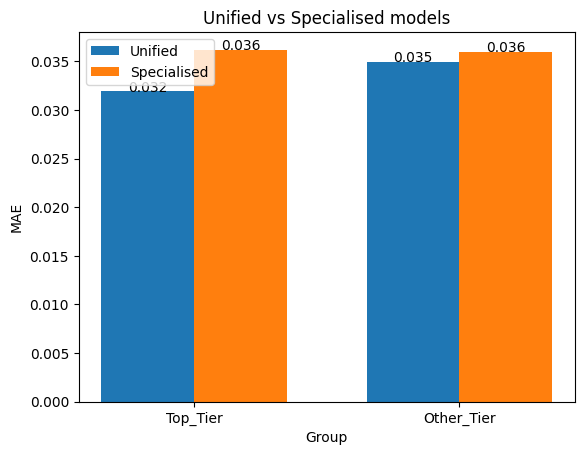

In [ ]:
#Section 6

print("\n")

print("Section 6: compare one model vs two models")

print("\n")


# 1. show a simple comparison table

groups = ["Top_Tier", "Other_Tier"]

unified_mae_list = [top_tier_mae, other_tier_mae]

special_mae_list = [top_tier_mae_specialised, other_tier_mae_specialised]


print("Group        Unified_MAE    Specialised_MAE")

print(groups[0], "   ", round(unified_mae_list[0], 4), "        ", round(special_mae_list[0], 4))

print(groups[1], "   ", round(unified_mae_list[1], 4), "        ", round(special_mae_list[1], 4))


# 2. work out bias before and after

old_bias = bias_amount

new_bias = top_tier_mae_specialised - other_tier_mae_specialised

if new_bias < 0:

    new_bias = new_bias * -1


# 3. percentage change in bias

bias_change_pct = 0

if old_bias != 0:

    bias_change_pct = (old_bias - new_bias) / old_bias

    bias_change_pct = bias_change_pct * 100


print("\nUnified model bias (absolute MAE difference):", bias_unified)
print("Specialised model bias (absolute MAE difference):", bias_specialised)
print("Bias reduction:", round(bias_change_pct, 2), "%")



# 4. say if it got better or worse

if new_bias < old_bias:

    print("Specialised models reduced the bias")

elif new_bias > old_bias:

    print("Specialised models increased the bias")

else:

    print("Bias stayed the same")


# positions for the two groups on x-axis

pos_top = 0

pos_other = 1

width = 0.35


# positions for unified and specialised bars

pos_top_unified = pos_top - width/2

pos_top_special = pos_top + width/2

pos_other_unified = pos_other - width/2

pos_other_special = pos_other + width/2


plt.figure()


# draw each bar

plt.bar(pos_top_unified, unified_mae_list[0], width, label="Unified",color="tab:blue")

plt.bar(pos_top_special, special_mae_list[0], width, label="Specialised", color="tab:orange")

plt.bar(pos_other_unified, unified_mae_list[1], width,color="tab:blue")

plt.bar(pos_other_special, special_mae_list[1], width,color="tab:orange")


plt.xticks([pos_top, pos_other], groups)

plt.xlabel("Group")

plt.ylabel("MAE")

plt.title("Unified vs Specialised models")


# add MAE numbers on top of bars

plt.text(pos_top_unified, unified_mae_list[0], str(round(unified_mae_list[0], 3)), ha='center')

plt.text(pos_top_special, special_mae_list[0], str(round(special_mae_list[0], 3)), ha='center')

plt.text(pos_other_unified, unified_mae_list[1], str(round(unified_mae_list[1], 3)), ha='center')

plt.text(pos_other_special, special_mae_list[1], str(round(special_mae_list[1], 3)), ha='center')


plt.legend()

plt.show()